Welcome to this comprehensive tutorial on **K-means clustering**! This hands-on lab will guide you through understanding, implementing, and applying one of the most fundamental unsupervised learning algorithms.


##  Lab Structure

This tutorial is organized into progressive sections:

1. **Implementation Phase** - Build K-means from scratch with step-by-step guidance
2. **Visualization & Analysis** - See the algorithm in action with interactive plots
3. **Parameter Tuning** - Learn to find the optimal number of clusters
4. **Scaling & Preprocessing** - Understand the importance of feature scaling
5. **Limitations & Alternatives** - Explore when K-means fails and what to use instead
6. **Evaluation Metrics** - Learn to assess clustering quality without ground truth

Let's dive in and start clustering! 


## Required Libraries & Setup

Before we dive into K-means clustering, let's import all the essential libraries we'll need throughout this tutorial. **Run the cell below** to set up your environment:

- **`utils.py`** - Contains custom helper functions for visualization and data loading specific to this assignment. You don't need to modify this file.

💡 **Tip:** If you encounter any import errors, make sure all required packages are installed in your environment!

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import make_blobs, make_circles
from utils import *

%matplotlib inline


##  Introduction to K-Means Clustering

### What is K-Means Clustering?

K-means is an **unsupervised learning algorithm** designed to automatically discover hidden patterns in data by grouping similar data points into clusters. It's one of the most widely used clustering algorithms in machine learning and data science.

#### The Problem Setup

* **Input**: A training set $\{x^{(1)}, x^{(2)}, ..., x^{(m)}\}$ where each $x^{(i)} \in \mathbb{R}^n$
* **Goal**: Partition the data into $K$ distinct, cohesive clusters
* **Output**: Cluster assignments and centroids that minimize within-cluster variance

### How K-Means Works: The Algorithm

K-means follows an **iterative optimization approach** with two main phases:

#### **Phase 1: Cluster Assignment**
Assign each data point to the nearest centroid

#### **Phase 2: Centroid Update** 
Move centroids to the center of their assigned points



#### Algorithm Pseudocode

```python
# Step 1: Initialize centroids
centroids = kMeans_init_centroids(X, K)

# Step 2: Iterate until convergence
for iteration in range(max_iterations):
    # Phase 1: Assign points to closest centroids
    idx = find_closest_centroids(X, centroids)
    
    # Phase 2: Update centroids to cluster means
    centroids = compute_centroids(X, idx, K)
```

### Mathematical Foundation

#### **Objective Function (Cost Function)**
K-means minimizes the **Within-Cluster Sum of Squares (WCSS)**:

$$J = \sum_{i=1}^{m} ||x^{(i)} - \mu_{c^{(i)}}||^2$$

Where:
- $x^{(i)}$ = $i$-th data point
- $\mu_{c^{(i)}}$ = centroid of cluster assigned to $x^{(i)}$
- $c^{(i)}$ = cluster assignment for point $i$

#### **The Two-Step Process**

1. **Assignment Step**: For each point $x^{(i)}$, find the closest centroid:
   $$c^{(i)} = \arg\min_j ||x^{(i)} - \mu_j||^2$$

2. **Update Step**: For each centroid $k$, compute the mean of assigned points:
   $$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x^{(i)}$$
   
   Where $C_k = \{i : c^{(i)} = k\}$ (set of points assigned to cluster $k$)


### Implementation Plan

In the following sections, you'll implement the two core functions:

1. **`find_closest_centroids()`** - Implements the assignment step
2. **`compute_centroids()`** - Implements the update step

💡 **Pro Tip**: Understanding these two functions deeply will give you complete mastery over how K-means works under the hood!


## Implementing K-Means from Scratch

### Finding Closest Centroids

In the “cluster assignment” phase of the K-means algorithm, the
algorithm assigns every training example $x^{(i)}$ to its closest
centroid, given the current positions of centroids. 


### **Task 1:**

Your task is to complete the code in `find_closest_centroids`. 

* This function takes the data matrix `X` and the locations of all
centroids inside `centroids` 
* It should output a one-dimensional array `idx` (which has the same number of elements as `X`) that holds the index  of the closest centroid (a value in $\{0,...,K-1\}$, where $K$ is total number of centroids) to every training example . *(Note: The index range 0 to K-1 varies slightly from what is shown in the lectures (i.e. 1 to K) because Python list indices start at 0 instead of 1)*
* Specifically, for every example $x^{(i)}$ we set
$$c^{(i)} := j \quad \mathrm{that \; minimizes} \quad ||x^{(i)} - \mu_j||^2,$$
where 
 * $c^{(i)}$ is the index of the centroid that is closest to $x^{(i)}$ (corresponds to `idx[i]` in the starter code), and 
 * $\mu_j$ is the position (value) of the $j$’th centroid. (stored in `centroids` in the starter code)
 * $||x^{(i)} - \mu_j||$ is the L2-norm


In [40]:
def find_closest_centroids(X, centroids):
    """
    Computes the centroid memberships for every example
    
    Args:
        X (ndarray): (m, n) Input values      
        centroids (ndarray): (K, n) centroids
    
    Returns:
        idx (array_like): (m,) closest centroids
    
    """

    # Set K
    K = centroids.shape[0]

    # You need to return the following variables correctly
    idx = np.zeros((X.shape[0], ), dtype=int)
     ### START CODE HERE ###
    for i in range(X.shape[0]):
        x = X[i,:] # getting the current x value
        # getting difference between x and all centroids
        difference = centroids - x
        # calculating L2 norm of each row as it is 
        l2_norm = np.sum(difference**2, axis = 1)
        # appending index of min norm as that is the index of the clossest centroid
        idx[i] = l2_norm.argmin()
     ### END CODE HERE ###
    return idx

Now let's check your implementation using an example dataset

In [41]:
# Load an example dataset that we will be using
X = np.load("ex7_X.npy")

The code below prints the first five elements in the variable `X` and the dimensions of the variable

In [42]:
print("First five elements of X are:\n", X[:5]) 
print('The shape of X is:', X.shape)

First five elements of X are:
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]
The shape of X is: (300, 2)


In [43]:
# Select an initial set of centroids (3 Centroids)
initial_centroids = np.array([[3,3], [6,2], [8,5]])

# Find closest centroids using initial_centroids
idx = find_closest_centroids(X, initial_centroids)

# Print closest centroids for the first three elements
print("First three elements in idx are:", idx[:3])


First three elements in idx are: [0 2 1]


**Expected Output**:
<table>
  <tr>
    <td> <b>First three elements in idx are<b></td>
    <td> [0 2 1] </td> 
  </tr>
</table>


### Computing Centroid Means

Given assignments of every point to a centroid, the second phase of the
algorithm recomputes, for each centroid, the mean of the points that
were assigned to it.



### **Task 2:**

Please complete the `compute_centroids` below to recompute the value for each centroid

* Specifically, for every centroid $\mu_k$ we set
  

$$
\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x^{(i)}
$$ 

where 

* $C_k$ is the set of examples that are assigned to centroid $k$
* $|C_k|$ is the number of examples in the set $C_k$


* Concretely, if two examples say $x^{(3)}$ and $x^{(5)}$ are assigned to centroid $k=2$,
then you should update $\mu_2 = \frac{1}{2}(x^{(3)}+x^{(5)})$.

In [44]:
def compute_centroids(X, idx, K):
    """
    Returns the new centroids by computing the means of the 
    data points assigned to each centroid.
    
    Args:
        X (ndarray):   (m, n) Data points
        idx (ndarray): (m,) Array containing index of closest centroid for each 
                       example in X. Concretely, idx[i] contains the index of 
                       the centroid closest to example i
        K (int):       number of centroids
    
    Returns:
        centroids (ndarray): (K, n) New centroids computed
    """
    
    # Useful variables
    m, n = X.shape
    
    # You need to return the following variables correctly
    centroids = np.zeros((K, n))
    
    ### START CODE HERE ###
    # iterate through all centroids - to update each one
    for i in range(K):
        # getting mask of which x values are in the current centroid
        mask = idx == i
        centroid_values = X[mask, :]
        # summing the columns and then dividing by the number of values assigned to the centroid - putting it in the new centroids array
        centroids[i] = np.sum(centroid_values, axis = 0) / centroid_values.shape[0]
    ### END CODE HERE ## 
    
    return centroids

Now check your implementation by running the cell below

In [45]:
K = 3
centroids = compute_centroids(X, idx, K)

print("The centroids are:", centroids)


The centroids are: [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


**Expected Output**:

2.42830111 3.15792418

5.81350331 2.63365645

7.11938687 3.6166844 


## K-Means on a Sample Dataset

After completing the two functions **`find_closest_centroids()`** and **`compute_centroids()`**, the next step is to run the K-Means algorithm on a simple 2D dataset to visualize how it works in practice.  

- Review the **`run_kMeans()`** function provided below to understand its workflow.  
- Notice that this function repeatedly calls the two functions you implemented inside an iterative loop.  

When you execute the code, it will generate a visualization showing how the algorithm progresses at each iteration.  

- By the end, your plot should look similar to **Figure 1**.  
- The **black X-marks** represent the final centroids located at the center of each colored cluster.  
- The **intermediate X-marks**, connected by lines, trace the movement of each centroid across iterations until convergence.  


<img src="images/figure 1.png" width="500" height="500">


**Note:** You do not need to implement anything for this section — simply run the code provided below.

In [46]:
# You do not need to implement anything for this part

def run_kMeans(X, initial_centroids, max_iters=100, plot_progress=False):
    """
    Runs the K-Means algorithm on data matrix X, where each row of X
    is a single example
    """
    
    # Initialize values
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids    
    idx = np.zeros(m)
    plt.figure(figsize=(8, 6))

    # Run K-Means
    for i in range(max_iters):
        
        #Output progress every 10 iterations
        if i % 10 == 0:
            print("K-Means iteration %d/%d" % (i, max_iters-1))
        
        # For each example in X, assign it to the closest centroid
        idx = find_closest_centroids(X, centroids)
        
        # Optionally plot progress
        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids
            
        # Given the memberships, compute new centroids
        centroids = compute_centroids(X, idx, K)
    plt.show() 
    return centroids, idx

K-Means iteration 0/99
K-Means iteration 10/99
K-Means iteration 20/99
K-Means iteration 30/99
K-Means iteration 40/99
K-Means iteration 50/99
K-Means iteration 60/99
K-Means iteration 70/99
K-Means iteration 80/99
K-Means iteration 90/99


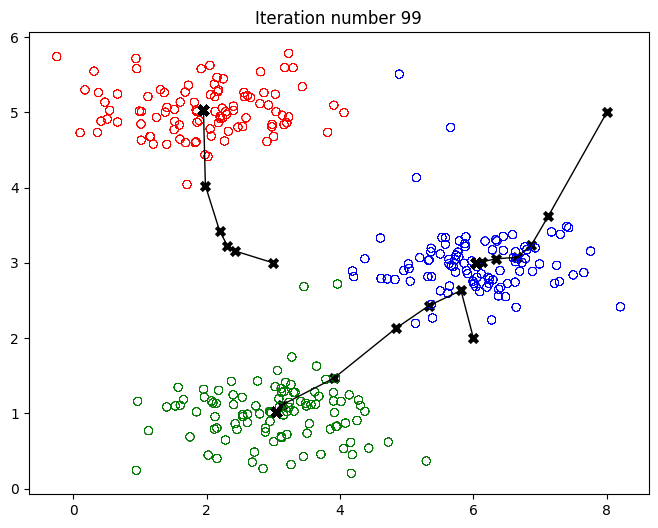

In [48]:
# Load an example dataset
X = np.load("ex7_X.npy") # changing it so it works

# Set initial centroids
initial_centroids = np.array([[3,3],[6,2],[8,5]])

# Number of iterations
max_iters = 10

# Run K-Means
centroids, idx = run_kMeans(X, initial_centroids, plot_progress=True)


##  Random initialization

The initial assignments of centroids for the example dataset was designed so that you will see the same figure as in Figure 1. In practice, a good strategy for initializing the centroids is to select random examples from the
training set.

In this part of the exercise, you should understand how the function `kMeans_init_centroids` is implemented.
* The code first randomly shuffles the indices of the examples (using `np.random.permutation()`). 
* Then, it selects the first $K$ examples based on the random permutation of the indices. 
* This allows the examples to be selected at random without the risk of selecting the same example twice.

**Note:** You do not need to implement anything for this section — simply run the code provided below.

In [49]:
# You do not need to modify this part

def kMeans_init_centroids(X, K):
    """
    This function initializes K centroids that are to be 
    used in K-Means on the dataset X
    
    Args:
        X (ndarray): Data points 
        K (int):     number of centroids/clusters
    
    Returns:
        centroids (ndarray): Initialized centroids
    """
    
    # Randomly reorder the indices of examples
    randidx = np.random.permutation(X.shape[0])
    
    # Take the first K examples as centroids
    centroids = X[randidx[:K]]
    
    return centroids

With this code, each run of the K-Means algorithm starts with **different randomly initialized centroids**, which can lead to **different clustering results**.  
Run the cell below several times and observe how the clusters vary depending on the initial centroid positions.

K-Means iteration 0/9


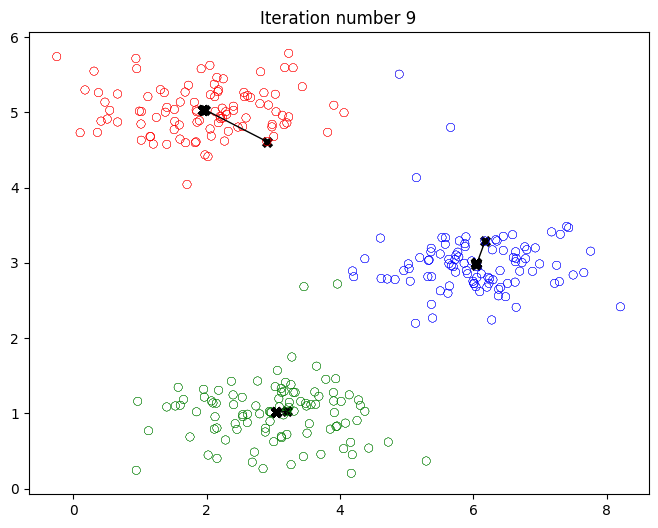

In [50]:
# Run this cell repeatedly to see different outcomes.

# Set number of centroids and max number of iterations
K = 3
max_iters = 10

# Set initial centroids by picking random examples from the dataset
initial_centroids = kMeans_init_centroids(X, K)

# Run K-Means
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

**Key Takeaway**

In K-Means, the **initial placement of centroids** plays a crucial role in how the algorithm converges.  
If the centroids are poorly initialized, clusters may shift dramatically across iterations, and the algorithm might reach the `max_iter` limit before properly converging — resulting in **suboptimal clusters**.  

The **[k-means++ algorithm](https://stackoverflow.com/questions/5466323/how-could-one-implement-the-k-means-algorithm)** was designed to address this issue by providing a smarter, more systematic way to initialize centroids.  

For additional discussion on why initialization matters, see this [post](https://stats.stackexchange.com/questions/246061/what-are-the-advantages-of-the-pre-defined-initial-centroids-in-clustering).


## Perform K-Means Clustering Using scikit-learn

Scikit-learn provides the **[`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)** class, which offers a convenient and efficient implementation of the K-Means clustering algorithm.  

In `sklearn.KMeans`, the **`n_init`** parameter helps improve clustering stability by controlling **how many times the algorithm runs with different random centroid initializations**.  
For each run, the algorithm computes the within-cluster sum of squared distances (inertia) and selects the result that yields the **lowest inertia**, i.e., the best clustering outcome.  

By default, scikit-learn uses **`init='k-means++'`**, which initializes centroids in a smarter way to speed up convergence and improve accuracy.  
The **`n_init`** parameter is typically set to **10**, meaning K-Means runs 10 times with different centroid seeds and returns the best result.


### **Task 3**

Let’s start by running K-Means with the **default settings** (`n_clusters=3`).  
Fill in the missing code sections according to the comments provided below.

The sklearn centroids are: [[3.04367119 1.01541041]
 [1.95399466 5.02557006]
 [6.03366736 3.00052511]]
The labels are: [1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1]
The SSE is: 266.6585196549193


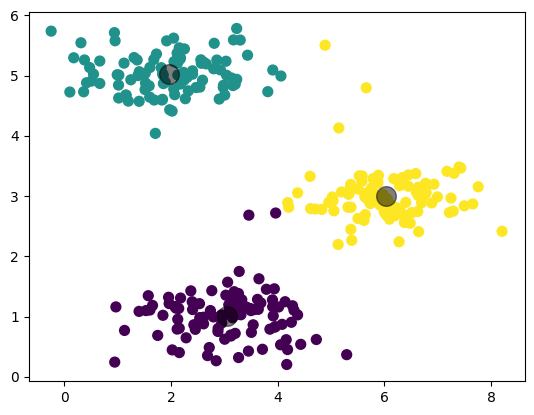

In [54]:
# run kmeans from sklearn on the X dataset, set k=3
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")


# Number of clusters
K = 3

# Fit KMeans and calculate centroids
kmeans = KMeans(n_clusters = 3)
kmeans.fit(X)

# get the SSE (sum of squared error), labels, and centroids
SSE = kmeans.inertia_
labels = kmeans.labels_
sklearn_centroids = kmeans.cluster_centers_

print("The sklearn centroids are:", sklearn_centroids)
print("The labels are:", labels)
print("The SSE is:", SSE)


#plot the clustering result on the data points
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

##  Selecting the Number of Clusters

A key limitation of K-Means is that you must **specify the number of clusters (`k`) in advance** — the algorithm cannot automatically determine it from the data.  
For example, if you tell K-Means to find **five clusters**, it will proceed to partition the data into five groups, even if that number doesn’t naturally fit the structure of the dataset.



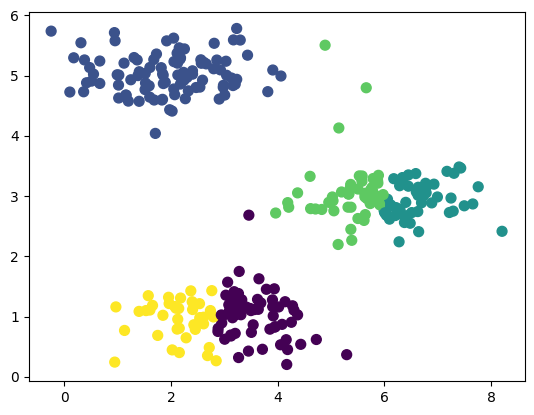

In [53]:
labels = KMeans(5, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');


In practice, methods such as the **Elbow Method** and the **Silhouette Score** are commonly used to help determine a suitable value for **`k`**.


#### Elbow Criterion

The **Elbow Method** helps determine the optimal number of clusters (**k**) by identifying the point where the **sum of squared errors (SSE)** sharply decreases before leveling off. SSE measures the squared distance between each data point and its assigned cluster centroid.

To apply this method, compute SSE for a range of k values and plot the results. As k increases, SSE naturally decreases and approaches zero when each data point forms its own cluster. The optimal number of clusters is typically found at the **“elbow point”** of the plot — where increasing k yields only marginal improvements in SSE.

The `inertia_` attribute returns the **within-cluster sum of squared distances**, which corresponds to the **SSE**_

Example:

```python
from sklearn.cluster import KMeans

# Example: given dataset X and number of clusters k
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

# Get SSE (Sum of Squared Errors)
sse = kmeans.inertia_
print(f"SSE for k={k}: {sse:.2f}")
```

### **Task 4:** 
Using the elbow method to find the optimal number of clusters using the following setting

```
n_clusters in range (1, 10)
max_iter=10

```

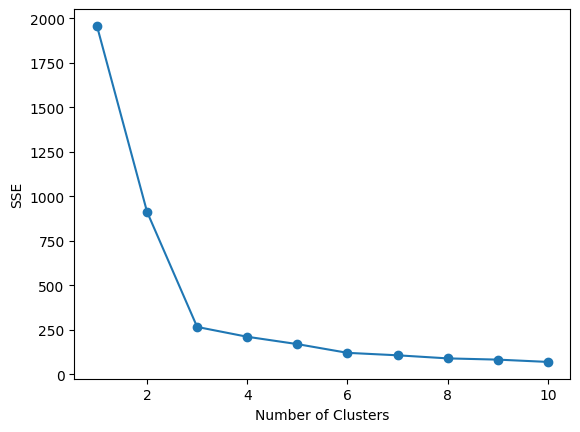

In [60]:
# use the elbow method to find the optimal number of clusters 
SSE_list = []
clusters_list = [i for i in range(1, 11)]
for clusters in range(1, 11):
    model = KMeans(n_clusters = clusters)
    model.fit(X)
    SSE_list.append(model.inertia_)

# plot the SSE for each n_clusters
plt.plot(clusters_list, SSE_list, '-o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.show()

We can see using the plotted SSE across clusters that the elbow, or optimal number of clusters, is at 3.

#### Silhouette Score

The [Silhouette Score](https://en.wikipedia.org/wiki/Silhouette_(clustering)) is a metric used to evaluate the quality of clustering results, particularly in K-Means clustering, by measuring the degree of separation between clusters.  
It quantifies how similar an object is to its own cluster compared to other clusters.  
The score ranges from **-1 to 1**, where **a higher score indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters**, suggesting a good clustering configuration.

To use the Silhouette Score to tune the number of clusters (**k**) for K-Means, one typically iterates over different values of **k** and computes the Silhouette Score for each result.  
The value of **k** that maximizes the Silhouette Score is usually considered the optimal number of clusters, as it indicates well-separated and cohesive clusters.

**Example: Compute the Silhouette Score using scikit-learn**

```python
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Example: given dataset X and number of clusters k
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# Compute Silhouette Score
score = silhouette_score(X, labels)
print(f"Silhouette Score for k={k}: {score:.3f}")
```


### **Task 5:**
Using the Silhouette Score  method to find the optimal number of clusters using the same setting as elbow method

```
n_clusters in range (2, 8)
max_iter=10

```

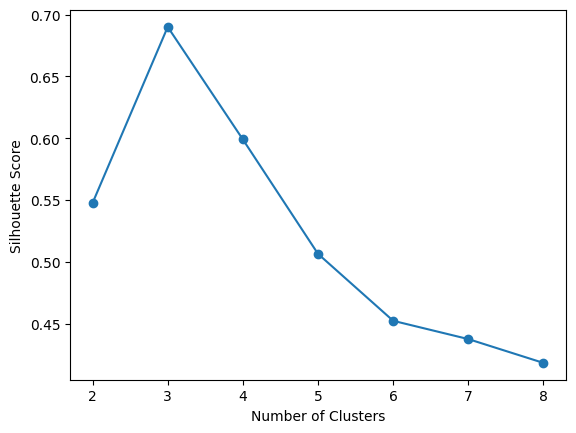

Optimal number of clusters based on the silhouette score is 3


In [62]:
# use silhouette score to find the optimal number of clusters
# step 1: import library
from sklearn.metrics import silhouette_score

# step 2: loop through different number of clusters and get the silhouette score
silhouette_list = []
clusters_list = [i for i in range(2, 9)]
for clusters in range(2, 9):
    model = KMeans(n_clusters = clusters)
    labels = model.fit_predict(X)
    silhouette_list.append(silhouette_score(X, labels))
# step 3: plot the silhouette scores for each n_clusters
plt.plot(clusters_list,silhouette_list, '-o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

# pick the optimal number of clusters based on the above analysis
print(f"Optimal number of clusters based on the silhouette score is {np.array(silhouette_list).argmax() + 2}")


## Feature Scaling in K-Means Clustering

K-Means clustering relies on **distance calculations** to assign data points to clusters.  
If features are on different scales, those with larger numeric ranges can **dominate the distance metric**, leading to biased cluster assignments.  
Therefore, **feature scaling** is an essential preprocessing step when applying K-Means.

Let's create a synthetic dataset to demonstrate this effect.


In [63]:
# Generate synthetic dataset with different scales
X, _ = make_blobs(n_samples=300, centers=4, random_state=42, cluster_std=[1, 2, 3, 4])
# Introduce different scales for features
X[:, 0] *= 10  # Increase scale for the first feature


In [64]:
# Perform K-means clustering without feature scaling
kmeans_unscaled = KMeans(n_clusters=3, random_state=42)
labels_unscaled = kmeans_unscaled.fit_predict(X)

In [66]:
# Perform K-means clustering with feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

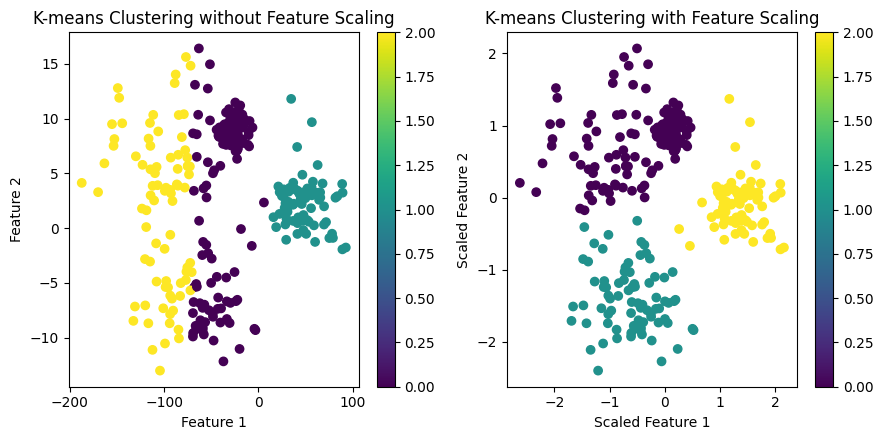

In [67]:
plt.figure(figsize=(9, 4.5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=labels_unscaled, cmap='viridis')
plt.title('K-means Clustering without Feature Scaling')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_scaled, cmap='viridis')
plt.title('K-means Clustering with Feature Scaling')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.colorbar()

plt.tight_layout()
plt.show()

You should observe that **without feature scaling**, K-Means clustering may **misclassify data points** because features with larger scales dominate the distance calculations.  
After applying **feature scaling**, the clusters should be **more accurately identified**, since K-Means now evaluates distances on a consistent scale across all features.

##  Demonstration of K-Means Assumptions

This section illustrates the conditions under which K-Means performs well versus when it begins to fail. We start with an ideal dataset (compact, well-separated, roughly spherical clusters), then progressively move to datasets that violate its assumptions.

###  Ideal (Assumption-Satisfying) Case
The following example shows clustered data that is:
- Compact and well separated
- Approximately circular (isotropic variance)
- Similar density and size across clusters

K-Means should recover clusters cleanly here.

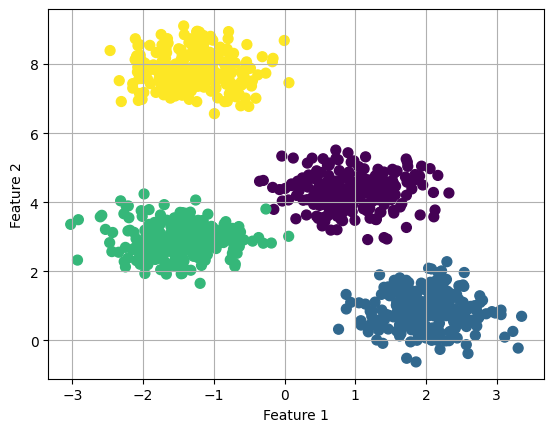

In [68]:
# Create a synthetic dataset with clear clusters
n_samples = 1000
n_components = 4

X_blob, true_labels_blob = make_blobs(n_samples=n_samples, centers=n_components, cluster_std=0.50, random_state=0)

plt.scatter(X_blob[:,0],X_blob[:,1], c=true_labels_blob, s=50, cmap='viridis')
plt.grid()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

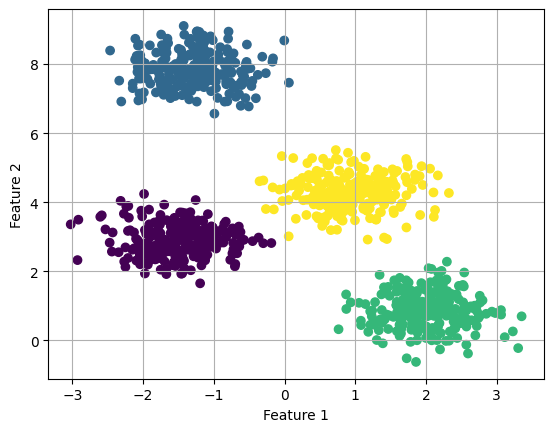

In [69]:
# fit kmeans on the X_blob dataset, k=4
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(X_blob)

cluster_labels_blob = kmeans.predict(X_blob)

plt.scatter(X_blob[:,0],X_blob[:,1], c=cluster_labels_blob)
plt.grid()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

###  Why K-Means Works Here
K-Means uses Euclidean distance to assign points to the nearest centroid, which implicitly favors circular (spherical) decision regions. When clusters are isotropic and similarly sized/dense, these circular boundaries align well with the data.

<img src="images/circle_kmeans.png" width="550" height="400">

This simplicity is a strength—but it also defines the limits of the algorithm.

###  Moving Toward Failure Cases
Real-world data often violates one or more of these conditions:
- Elongated / anisotropic clusters
- Nested or non-convex shapes (e.g., concentric circles)
- Unequal variance across clusters
- Strongly imbalanced cluster sizes

Next we explicitly construct datasets to surface these failure modes before introducing alternatives designed to handle them.

##  Demonstration of K-Means Limitations
We now build synthetic datasets that break K-Means’ assumptions and visualize how the algorithm behaves. Compare the ground truth with the K-Means assignments to see where and why it fails.

#### Data Generation

In [70]:
# Now, let's create datasets that violate K-Means assumptions
n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X, y = make_blobs(n_samples=n_samples, random_state=random_state)

X_circ, y_circ = make_circles(n_samples=n_samples, noise=0.1, random_state=0, factor=0.4)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)  # Unequal variance
X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
)  # Unevenly sized blobs
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

#### Data visualization

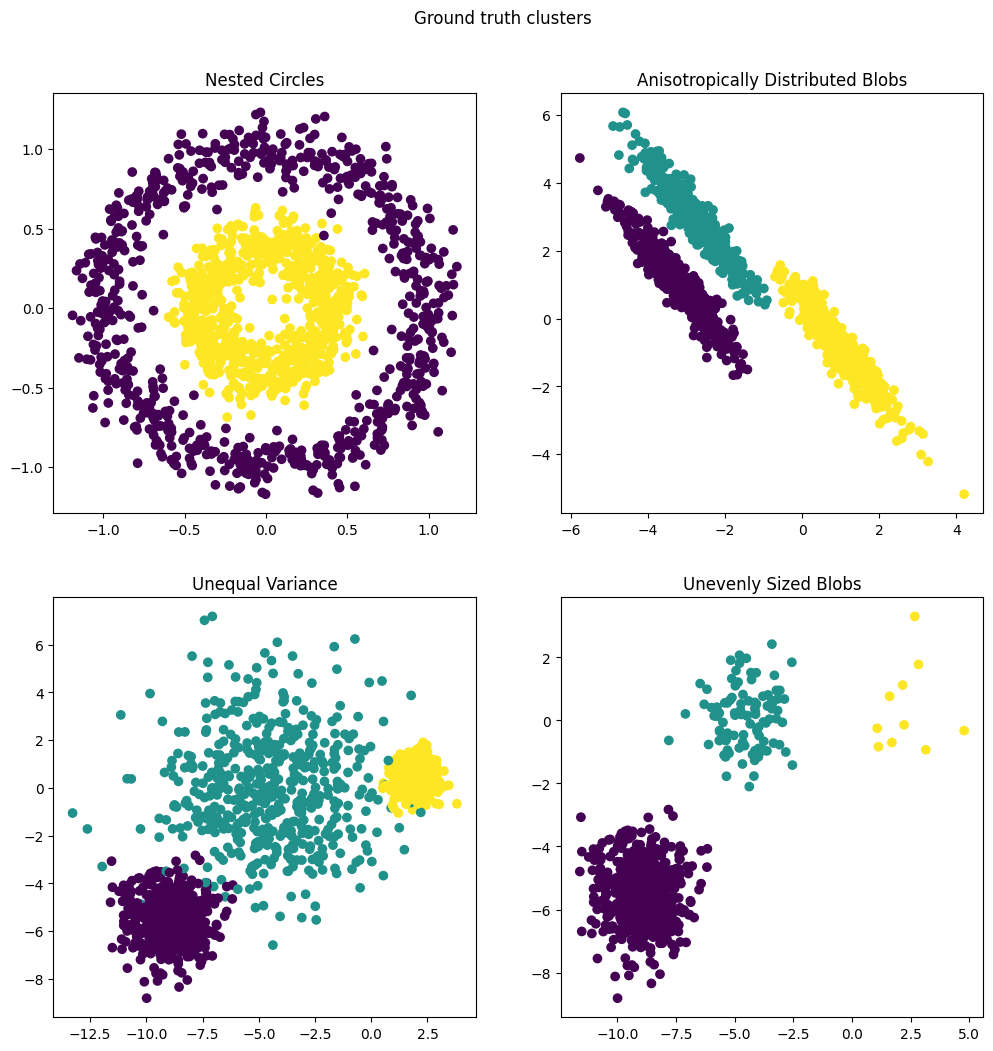

In [71]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ)
axs[0, 0].set_title("Nested Circles")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()

### **Task 6:**
Fitting k-means and plot results using the default setting and the correct number of clusters, which can be found in the above data visulization


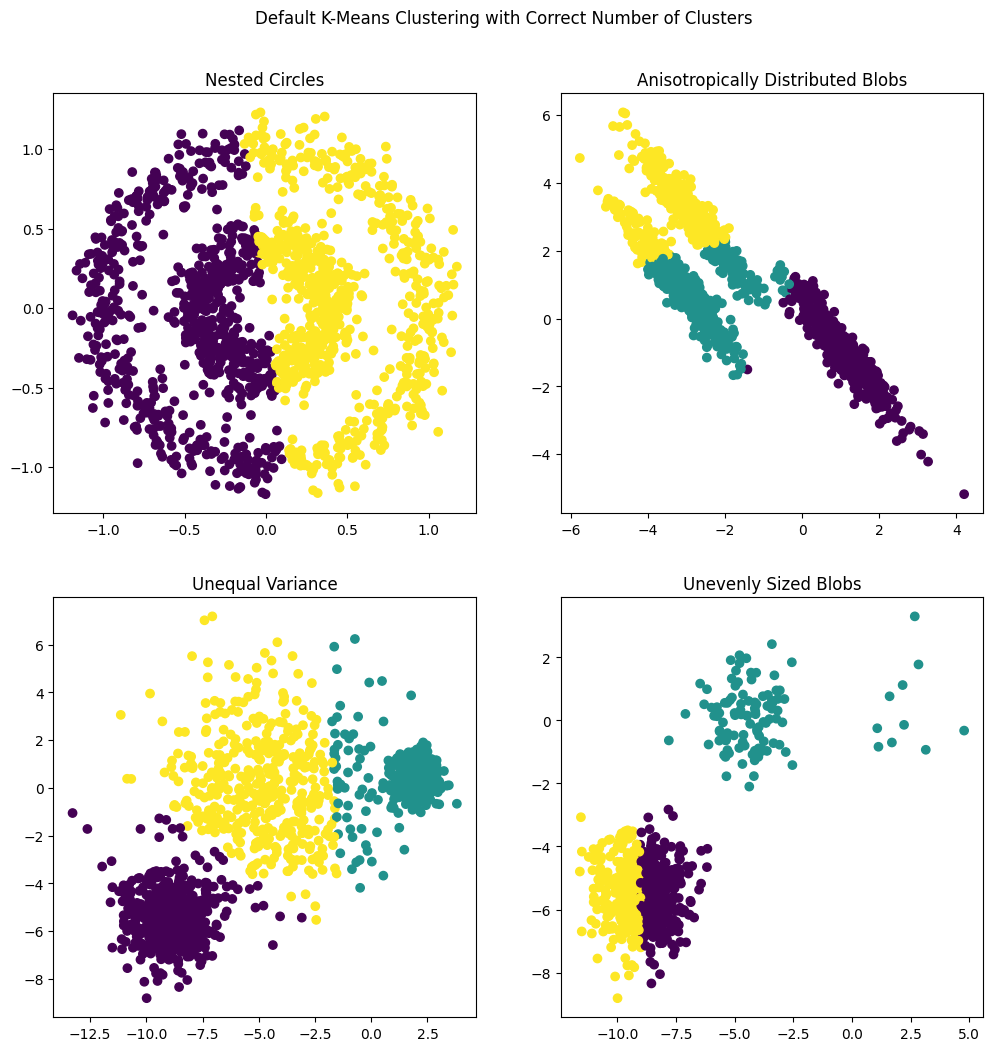

In [75]:
circ_means = KMeans(n_clusters = 2)
circ_labels = circ_means.fit_predict(X_circ)

aniso_means = KMeans(n_clusters = 3)
aniso_labels = aniso_means.fit_predict(X_aniso)

varied_means = KMeans(n_clusters = 3)
varied_labels = varied_means.fit_predict(X_varied)

filtered_means = KMeans(n_clusters = 3)
filtered_labels = filtered_means.fit_predict(X_filtered)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X_circ[:, 0], X_circ[:, 1], c=circ_labels)
axs[0, 0].set_title("Nested Circles")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=aniso_labels)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=varied_labels)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=filtered_labels)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Default K-Means Clustering with Correct Number of Clusters").set_y(0.95)
plt.show()

You can see from the plots above that **K-Means fails in all four cases**:

- It struggles with **non-spherical shapes** (e.g., concentric circles).  
- It performs poorly on **anisotropic (elongated) distributions**.  
- It cannot handle **clusters with unequal variances**.  
- It misclassifies **clusters of different sizes**.

These limitations arise because K-Means assumes clusters are **spherical, equally sized, and have similar densities**.

Next, let's explore how we can **overcome these limitations** using more flexible clustering algorithms.


###  Clustering Unevenly Sized Blobs

To handle **unevenly sized blobs**, you can increase the number of random initializations.  
In this example, we set **`n_init=15`** to reduce the chance of finding a suboptimal local minimum.


### **Task 7**

Run K-Means again, this time setting **`n_init=15`**, and plot the resulting clusters.



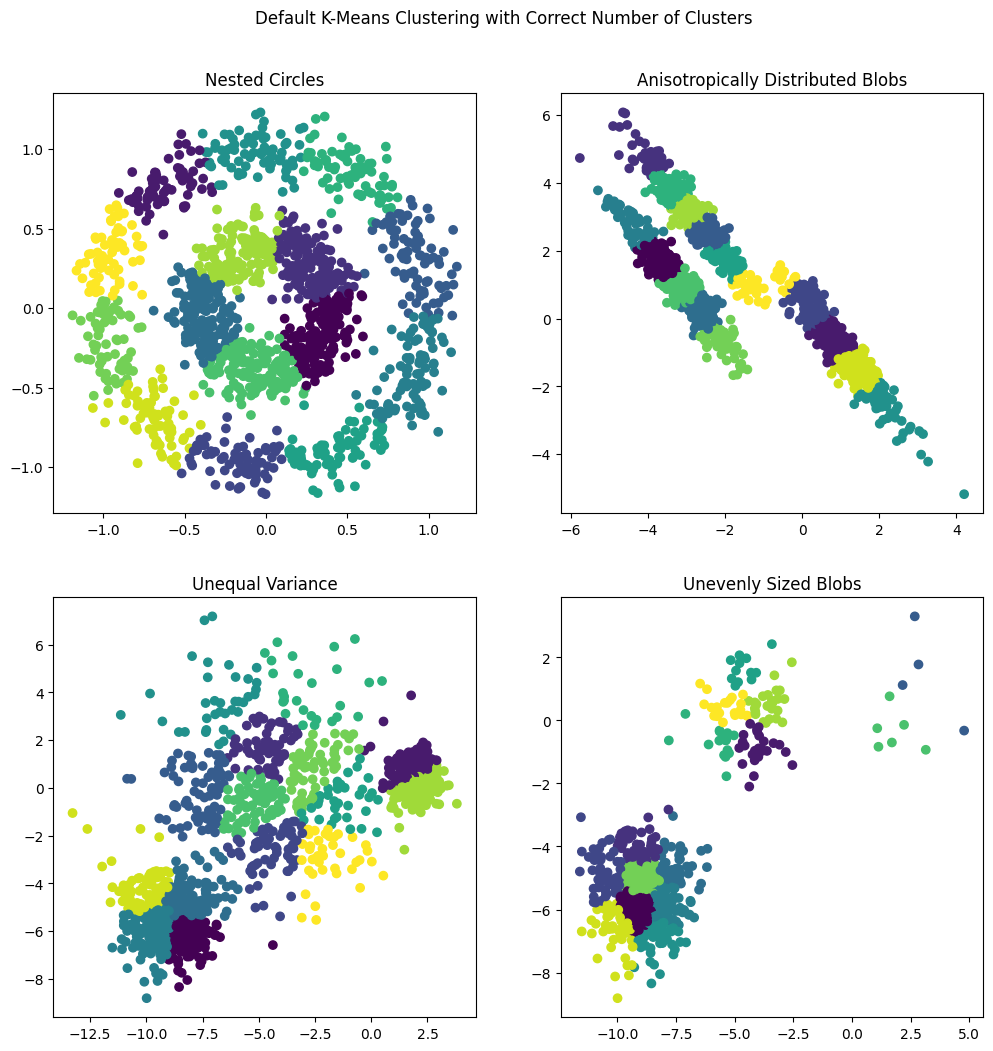

In [76]:
circ_means = KMeans(n_clusters = 15)
circ_labels = circ_means.fit_predict(X_circ)

aniso_means = KMeans(n_clusters = 15)
aniso_labels = aniso_means.fit_predict(X_aniso)

varied_means = KMeans(n_clusters = 15)
varied_labels = varied_means.fit_predict(X_varied)

filtered_means = KMeans(n_clusters = 15)
filtered_labels = filtered_means.fit_predict(X_filtered)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X_circ[:, 0], X_circ[:, 1], c=circ_labels)
axs[0, 0].set_title("Nested Circles")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=aniso_labels)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=varied_labels)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=filtered_labels)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Default K-Means Clustering with Correct Number of Clusters").set_y(0.95)
plt.show()

As can be observed, increasing the number of random initializations in K-means clustering can improve the clustering of unevenly sized blobs by providing the algorithm with more opportunities to explore different starting points for centroids and select the configuration that best fits the data

##  Alternative Clustering Methods to Overcome K-Means Limitations

K-means clustering has limitations when dealing with certain types of data distributions, such as nested, anisotropic, and unequal variances. here we propose some other clustering algorithms, such as

* Density-Based Spatial Clustering of Applications with Noise (DBSCAN)
```
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(data)
```
* Agglomerative Hierarchical Clustering
```
from sklearn.cluster import AgglomerativeClustering
agg_clustering = AgglomerativeClustering(n_clusters=3)
clusters = agg_clustering.fit_predict(data)
```
* Gaussian Mixture Models 
```
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3)
gmm.fit(data)
clusters = gmm.predict(data)
```

Let's next apply them to fit the data and see whether they are able to capture the pattern


### **Task 8:**
Apply these three algorithms to the challenging datasets and visually compare results with K-Means:
- For GaussianMixture and Agglomerative, set the number of clusters equal to K-Means
- For DBSCAN, use: `eps=0.11` (Nested Circles), `eps=0.4, min_samples=10` (Anisotropic), `eps=0.9, min_samples=10` (Unequal Variance)

### Gaussian Mixture Models (GMM)

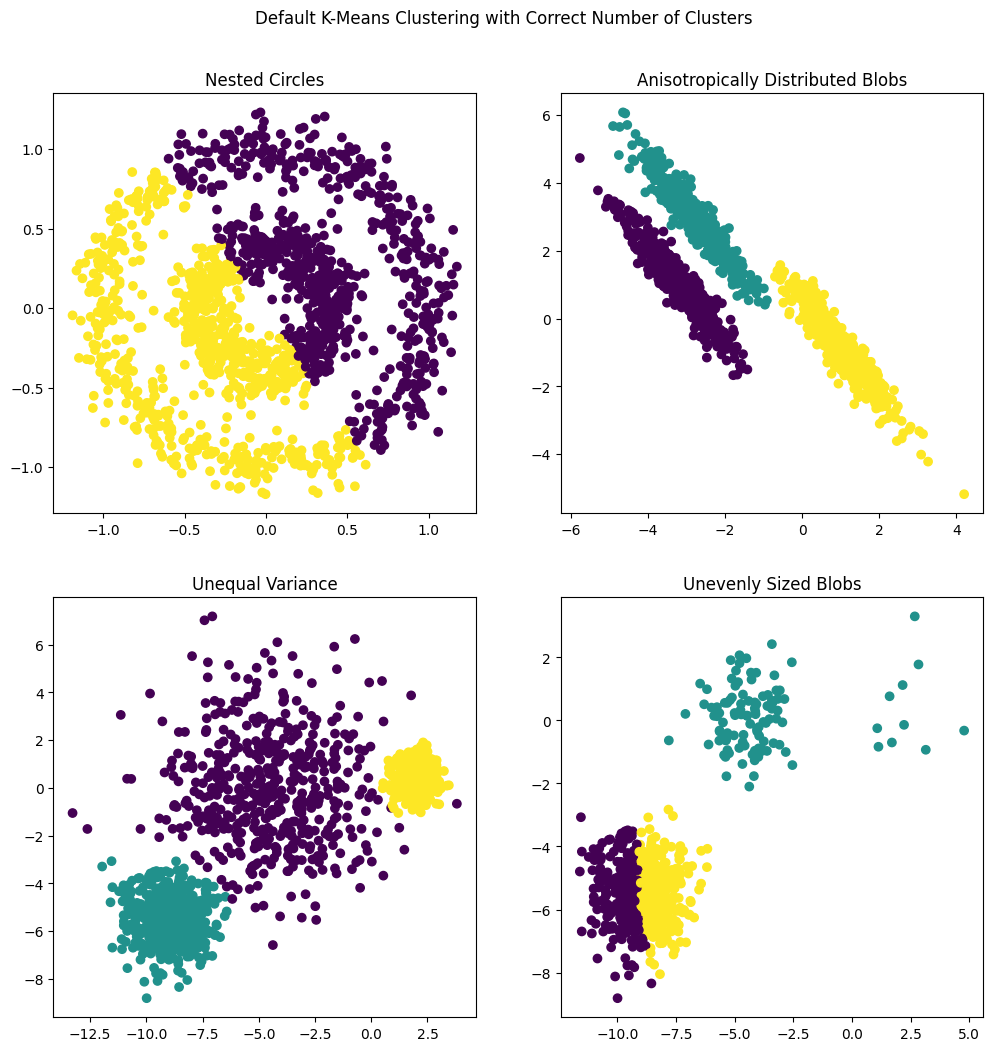

In [ ]:
from sklearn.mixture import GaussianMixture

circ_means = GaussianMixture(n_components = 2)
circ_means.fit(X_circ)
circ_labels = circ_means.predict(X_circ)

aniso_means = GaussianMixture(n_components = 3)
aniso_means.fit(X_aniso)
aniso_labels = aniso_means.fit_predict(X_aniso)

varied_means = GaussianMixture(n_components = 3)
varied_means.fit(X_varied)
varied_labels = varied_means.fit_predict(X_varied)

filtered_means = GaussianMixture(n_components = 3)
filtered_means.fit(X_filtered)
filtered_labels = filtered_means.fit_predict(X_filtered)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X_circ[:, 0], X_circ[:, 1], c=circ_labels)
axs[0, 0].set_title("Nested Circles")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=aniso_labels)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=varied_labels)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=filtered_labels)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Default K-Means Clustering with Correct Number of Clusters").set_y(0.95)
plt.show()

### DBSCAN

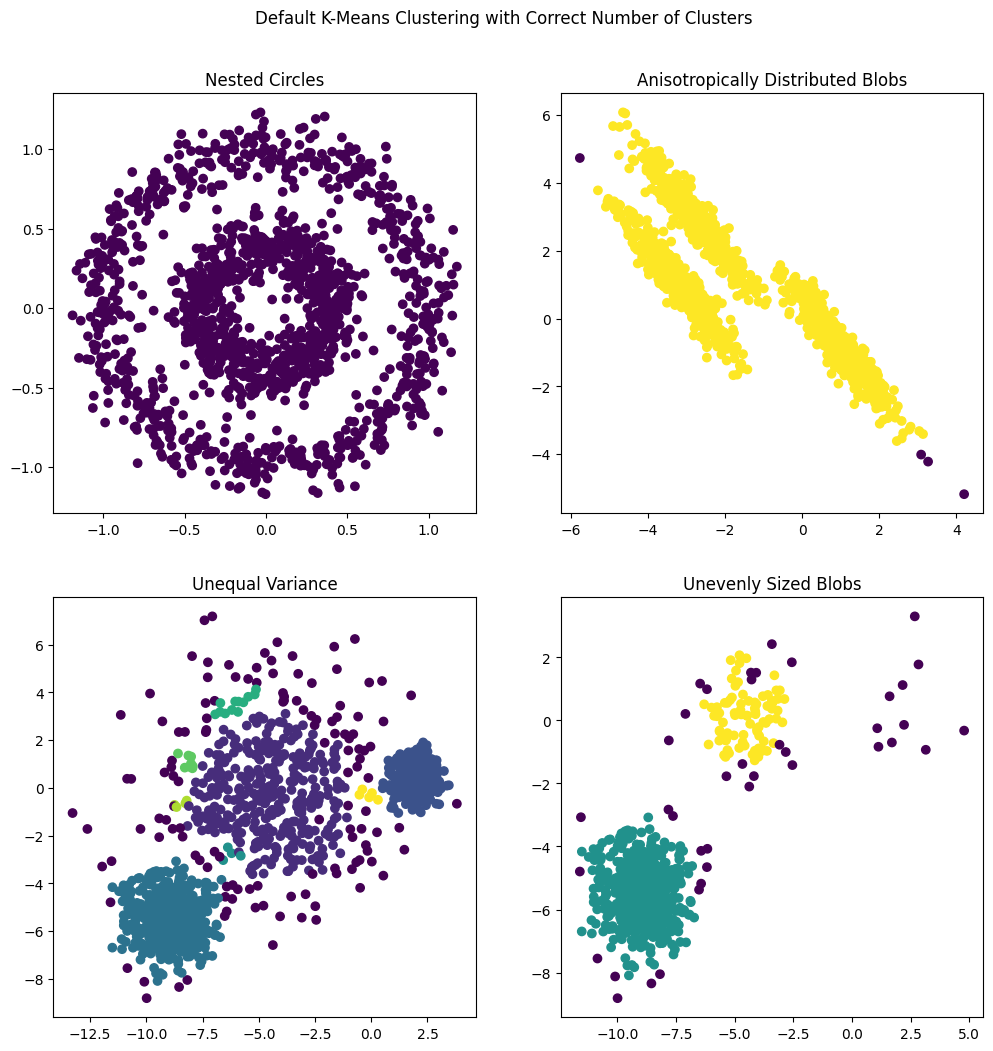

In [79]:
# use dbscan to cluster the X dataset

from sklearn.cluster import DBSCAN

circ_means = DBSCAN(eps = 0.5, min_samples = 5)
circ_labels = circ_means.fit_predict(X_circ)

aniso_means = DBSCAN(eps = 0.5, min_samples = 5)
aniso_labels = aniso_means.fit_predict(X_aniso)

varied_means = DBSCAN(eps = 0.5, min_samples = 5)
varied_labels = varied_means.fit_predict(X_varied)

filtered_means = DBSCAN(eps = 0.5, min_samples = 5)
filtered_labels = filtered_means.fit_predict(X_filtered)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X_circ[:, 0], X_circ[:, 1], c=circ_labels)
axs[0, 0].set_title("Nested Circles")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=aniso_labels)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=varied_labels)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=filtered_labels)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Default K-Means Clustering with Correct Number of Clusters").set_y(0.95)
plt.show()

### Agglomerative (Hierarchical) Clustering

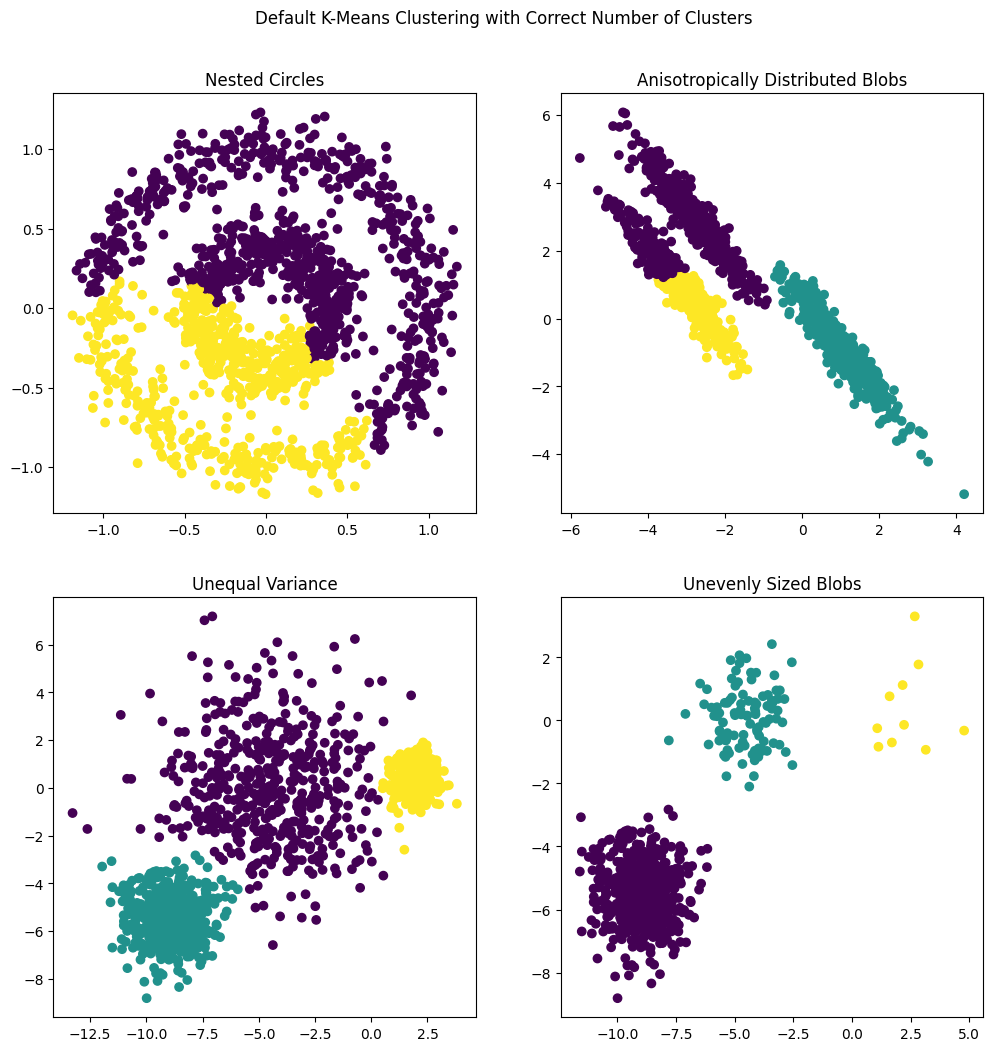

In [80]:
# use agglomerative clustering to cluster the X dataset
from sklearn.cluster import AgglomerativeClustering

circ_means = AgglomerativeClustering(n_clusters = 2)
circ_labels = circ_means.fit_predict(X_circ)

aniso_means = AgglomerativeClustering(n_clusters = 3)
aniso_labels = aniso_means.fit_predict(X_aniso)

varied_means = AgglomerativeClustering(n_clusters = 3)
varied_labels = varied_means.fit_predict(X_varied)

filtered_means = AgglomerativeClustering(n_clusters = 3)
filtered_labels = filtered_means.fit_predict(X_filtered)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X_circ[:, 0], X_circ[:, 1], c=circ_labels)
axs[0, 0].set_title("Nested Circles")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=aniso_labels)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=varied_labels)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=filtered_labels)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Default K-Means Clustering with Correct Number of Clusters").set_y(0.95)
plt.show()


Agglomerative clustering, like K-Means, also struggles with **nested clusters** due to its hierarchical nature.  
When using **single linkage**, it tends to merge clusters based on the **minimum distance between their nearest points**, which can lead to incorrect cluster merges in complex or nested structures.



## Clustering Performance Evaluation

In unsupervised learning, we often assess clustering quality along three complementary dimensions:

1. **Internal validation** – measures structure, cohesion, and separation using only the feature data and predicted cluster labels.  
2. **External validation** – compares clustering results against known ground truth labels (when available).  
3. **Visual / qualitative inspection** – uses plots or projections for human interpretation.

Below are the most commonly used evaluation methods.



###  Internal Metrics (No Ground Truth Needed)

**Primary:** **Silhouette Score** *(recommended default)*  
- **Intuition:** Measures how similar each point is to its own cluster versus the nearest other cluster.  
- **Range:** –1 to 1. Higher is better (> 0.5 often good; near 0 ambiguous; negative indicates misassignment).  
- **Strengths:** Scale-invariant, easy to compare across different `k` values, and broadly applicable.

**Other internal metrics:**
- **Davies–Bouldin Index (DBI):** Average ratio of within-cluster scatter to between-centroid distance. Lower is better. Useful as a secondary check but less interpretable than Silhouette.  
- *(Also seen: Calinski–Harabasz Index, Dunn Index – not used here.)*

**Example (Silhouette):**
```python
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 3
labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
score = silhouette_score(X, labels)
print(f"Silhouette Score (k={k}): {score:.3f}")
```

###  External Metrics (Require Ground Truth Labels)

Use these only when **true labels are available** — e.g., for benchmarking on synthetic or annotated datasets.

**Primary:** **Adjusted Rand Index (ARI)**  
- Adjusted for chance; range roughly –1 to 1 (1 = perfect agreement, 0 ≈ random label agreement).  
- Robust, symmetric, and widely used.

**Other:**  
- **Normalized Mutual Information (NMI):** Measures shared information between cluster assignments and true labels, normalized to [0, 1].  
  Less sensitive to label permutation than raw mutual information.

**Example (ARI & NMI):**
```python
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# y_true: ground truth labels; labels: predicted cluster labels
ari = adjusted_rand_score(y_true, labels)
nmi = normalized_mutual_info_score(y_true, labels)
print(f"ARI: {ari:.3f}  |  NMI: {nmi:.3f}")
```

###  Visual / Qualitative Evaluation

- **Scatter plots** using 2D data or PCA / t-SNE / UMAP projections for high-dimensional datasets.  
- **Centroid or prototype visualization** (e.g., mean images in image clustering).  
- **Cluster size distribution** to detect imbalance or fragmentation.  
- **Decision boundary overlays** (when feasible) for visual intuition.



### Choosing What to Report

- **No ground truth:** Use **Silhouette Score** across candidate **`k`** values (optionally add DBI) and visualizations.  
- **With ground truth:** Report **ARI** (and optionally **NMI**) along with an internal metric for structural insight.  
- Always include **visualizations** — metrics alone can miss geometric or topological issues (e.g., elongated or chained clusters).



### Common Pitfalls

- Very high Silhouette with very small clusters can indicate **over-segmentation**.  
- Low ARI/NMI doesn’t always mean failure — ground truth labels may encode **semantic** rather than geometric differences.  
- High internal metrics do not guarantee **usefulness for downstream tasks** — always consider domain context.


## Congratulations!
In this lab, you have
* Implemented the one of the most widely used clustering algorithms - K-means.
* Learned different perspectives of K-means.
* Explored other alternative clutering algorithms to overcome the limitations of K-means

## Reference:
https://www.deeplearning.ai/
